In [1]:
import geopandas as gpd
import pandas as pd

import mapillary as mly
import json



### netzwerk einlesen

In [2]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
cycleways=gpd.read_file("../preprocessing/processed_osm_files/processed_cycleways_germany_250528.geojson.gz")


In [3]:
cycleways

,osm_id,highway,bicycle,cycleway,cycleway_left,cycleway_opposite,cycleway_right,cycleway_both,cycleway_lane,cycleway_track,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
0,92,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimstraße,None,asphalt,None,"LINESTRING (13.73698 51.01663, 13.73752 51.016..."
1,93,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimberg,None,asphalt,None,"LINESTRING (13.73939 51.01669, 13.73967 51.016..."
2,99,tertiary,None,None,None,None,no,None,None,None,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
3,103,residential,None,None,None,None,None,None,None,None,5,None,None,None,None,Altmockritz,None,None,None,"LINESTRING (13.74127 51.01615, 13.74149 51.016..."
4,104,unclassified,None,None,None,None,None,no,None,None,50,None,None,None,None,Münzmeisterstraße,None,asphalt,None,"LINESTRING (13.74142 51.02366, 13.74139 51.023..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7336294,1390548863,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38298 52.65611, 11.383 52.6558,..."
7336295,1390548864,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38251 52.65568, 11.38266 52.655..."
7336296,1390548865,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38262 52.65609, 11.38266 52.655..."
7336297,1390550366,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,grass,None,"LINESTRING (13.87816 52.08202, 13.87811 52.08226)"


In [ ]:
filtered_bicycle= cycleways[
    (cycleways["bicycle"].isin(["yes", "designated"])   
     ) 
# woul dneed to add, but would need to create new network first: 
# cycleways["sidewalk_bicycle"].isin(["yes"])
# cycleways["sidewalk_right_bicycle"].isin(["yes"])
# cycleways["sidewalk_left_bicycle"].isin(["yes"])
# cycleways["sidewalk_both_bicycle"].isin(["yes"])

]
filtered_bicycle

,osm_id,highway,bicycle,cycleway,cycleway_left,cycleway_opposite,cycleway_right,cycleway_both,cycleway_lane,cycleway_track,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
21,2177,unclassified,yes,None,None,None,None,no,None,None,30,None,None,None,None,Kreuzstraße,None,asphalt,5.4,"LINESTRING (11.68861 47.90971, 11.6878 47.9096..."
44,367497,footway,yes,None,None,None,None,None,None,None,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.76219 48.17702, 11.76145 48.176..."
77,1198146,track,yes,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ground,None,"LINESTRING (8.54081 49.87498, 8.5414 49.87508,..."
168,1881030,pedestrian,yes,None,None,None,None,None,None,None,None,None,None,None,None,Georg-Schüler-Platz,None,paving_stones,None,"LINESTRING (8.56081 49.86068, 8.56084 49.86068..."
196,2129436,residential,yes,None,None,None,None,separate,None,None,30,None,None,None,None,Kastelburgstraße,None,asphalt,None,"LINESTRING (11.41893 48.15742, 11.4193 48.1575..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7336246,1390531260,secondary,yes,None,None,None,None,None,None,None,50,None,None,None,None,Füssener Straße,St 2520,asphalt,None,"LINESTRING (10.41885 47.66658, 10.41902 47.666..."
7336271,1390534024,footway,designated,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (7.12815 51.52736, 7.12828 51.52737..."
7336278,1390547304,residential,yes,None,None,None,None,no,None,None,30,None,None,None,DE:zone30,Bärensteinstraße,None,asphalt,None,"LINESTRING (13.56704 52.54126, 13.56704 52.541..."
7336279,1390547305,residential,yes,None,None,None,None,no,None,None,30,None,None,None,DE:zone30,Bärensteinstraße,None,asphalt,None,"LINESTRING (13.56703 52.54094, 13.56703 52.541..."


In [6]:
filtered_bicycle.highway.value_counts()

highway
path              430185
track             186078
footway           176522
service            47820
residential        42479
cycleway           32386
unclassified       15955
pedestrian         13477
tertiary            8450
secondary           8221
living_street       5544
primary             3619
steps               2516
construction         650
trunk                415
bridleway            386
trunk_link           371
secondary_link       126
primary_link         119
proposed             114
platform             100
tertiary_link         65
elevator              31
busway                21
motorway_link         19
bus_stop              13
corridor               9
road                   7
crossing               5
no                     3
disused                2
yes                    1
rest_area              1
planned                1
passing_place          1
Name: count, dtype: int64

In [ ]:
# # mapillary map feature data: != traffic signs
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE

# mapillary_mapfeaturepoints = gpd.read_parquet("../preprocessing/mapillary_map-feature-points_data_bbb_2025-06-11.parquet")
# mapillary_mapfeaturepoints


# LANE MARKINGS!!!
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE
# mapillary_mapfeaturepoints_bclane=mapillary_mapfeaturepoints[mapillary_mapfeaturepoints.value=="marking--discrete--symbol--bicycle"]
# mapillary_mapfeaturepoints_bclane

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y
0,POINT (11.27341 53.11882),2021-07-03,118488700476446,2021-07-03,object--traffic-sign--front,8705,5328
1,POINT (11.27681 53.11384),2021-07-03,1283980285353032,2021-07-03,object--street-light,8705,5328
2,POINT (11.27773 53.10978),2021-07-03,398107614960247,2021-07-03,object--traffic-sign--front,8705,5328
3,POINT (11.27341 53.11882),2021-07-03,118488687143114,2021-07-03,object--traffic-sign--front,8705,5328
4,POINT (11.27292 53.11977),2021-07-03,118488703809779,2021-07-03,object--traffic-sign--front,8705,5328
...,...,...,...,...,...,...,...
2894575,POINT (14.73256 51.65574),2024-06-28,1170872657387552,2024-06-28,object--traffic-sign--front,8862,5437
2894576,POINT (14.73306 51.64995),2024-06-28,991198522456798,2024-06-28,object--traffic-sign--front,8862,5437
2894577,POINT (14.73267 51.6557),2024-06-28,1170872647387553,2024-06-28,object--traffic-sign--temporary-front,8862,5437
2894578,POINT (14.73256 51.65574),2024-06-28,1170872660720885,2024-06-28,object--traffic-sign--front,8862,5437


In [7]:

## TRAFFFIC SIGNS
# https://www.mapillary.com/developer/api-documentation/traffic-signs?locale=

# Unterschiedliche Verkehrszeichen in Deutschland für Radwege

# # https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:237
# de_237="regulatory--bicycles-only--g1"

# # https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:240
# de_240="regulatory--shared-path-pedestrians-and-bicycles--g1"

# # https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-30
# de_241_30="regulatory--dual-path-bicycles-and-pedestrians--g1"

# # https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-31
# de_241_31="regulatory--dual-path-pedestrians-and-bicycles--g1"


# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:1022-10
de_1022_10="complementary--except-bicycles--g1" 



mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_ger_2025-06-07.parquet")


# Schilder in Germany
mapillary_trafficsigns_bc=mapillary_trafficsigns[mapillary_trafficsigns.value.isin([de_1022_10])]
mapillary_trafficsigns_bc

,geometry,first_seen_at,id,last_seen_at,value
243,POINT (5.89721 51.01692),2024-06-13,987942049632710,2024-06-13,complementary--except-bicycles--g1
3472,POINT (6.01264 51.78816),2025-02-08,944044634518237,2025-02-08,complementary--except-bicycles--g1
3475,POINT (6.00453 51.79049),2018-03-17,161492969314788,2018-03-17,complementary--except-bicycles--g1
3486,POINT (6.00417 51.79062),2025-05-10,644781515227110,2025-05-10,complementary--except-bicycles--g1
3527,POINT (6.01188 51.78829),2025-02-08,510083341688396,2025-05-10,complementary--except-bicycles--g1
...,...,...,...,...,...
5347946,POINT (14.98767 51.14965),2018-11-02,2904480049823918,2018-11-02,complementary--except-bicycles--g1
5347992,POINT (14.99714 51.14925),2022-07-28,2149980138490230,2022-07-28,complementary--except-bicycles--g1
5348104,POINT (15.01848 51.25642),2020-09-18,551546082917010,2020-09-18,complementary--except-bicycles--g1
5348181,POINT (15.01194 51.24349),2016-01-05,1360725794693920,2022-12-10,complementary--except-bicycles--g1


In [8]:
from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

mapillary_trafficsigns_bc_1year = mapillary_trafficsigns_bc[
    mapillary_trafficsigns_bc.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 12, axis=1)
]
mapillary_trafficsigns_bc_1year

,geometry,first_seen_at,id,last_seen_at,value
3655,POINT (6.00439 51.79055),2023-03-28,5846165332172176,2025-05-10,complementary--except-bicycles--g1
4005,POINT (6.00423 51.79055),2023-03-28,5846165305505512,2025-05-10,complementary--except-bicycles--g1
15775,POINT (6.08066 50.7802),2022-01-10,677337050304843,2024-07-21,complementary--except-bicycles--g1
16595,POINT (6.07281 50.77062),2014-07-30,6174413145918195,2025-04-07,complementary--except-bicycles--g1
16623,POINT (6.08127 50.77368),2018-04-21,288821452788626,2022-07-11,complementary--except-bicycles--g1
...,...,...,...,...,...
5344405,POINT (14.98522 51.12925),2016-09-28,1012585542481181,2024-04-20,complementary--except-bicycles--g1
5344730,POINT (14.97872 51.11656),2016-08-24,460097181719875,2024-04-20,complementary--except-bicycles--g1
5346974,POINT (14.98763 51.15142),2019-02-28,337624527706243,2024-06-18,complementary--except-bicycles--g1
5348181,POINT (15.01194 51.24349),2016-01-05,1360725794693920,2022-12-10,complementary--except-bicycles--g1


<Axes: >

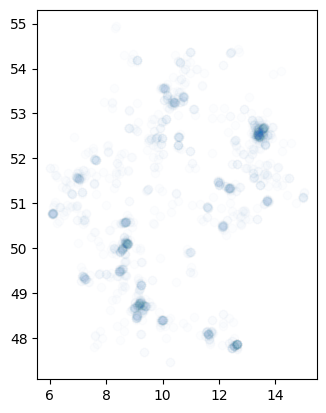

In [9]:
mapillary_trafficsigns_bc_1year.plot(alpha=0.01)

In [11]:
df_buffered = mapillary_trafficsigns_bc_1year.to_crs(25833).copy()
df_buffered["geometry"] = df_buffered.geometry.buffer(50)
df_buffered = df_buffered.to_crs(mapillary_trafficsigns_bc_1year.crs)
df_buffered

,geometry,first_seen_at,id,last_seen_at,value
3655,"POLYGON ((6.0051 51.7906, 6.00511 51.79056, 6....",2023-03-28,5846165332172176,2025-05-10,complementary--except-bicycles--g1
4005,"POLYGON ((6.00495 51.7906, 6.00495 51.79056, 6...",2023-03-28,5846165305505512,2025-05-10,complementary--except-bicycles--g1
15775,"POLYGON ((6.08137 50.78026, 6.08137 50.78021, ...",2022-01-10,677337050304843,2024-07-21,complementary--except-bicycles--g1
16595,"POLYGON ((6.07351 50.77068, 6.07351 50.77063, ...",2014-07-30,6174413145918195,2025-04-07,complementary--except-bicycles--g1
16623,"POLYGON ((6.08197 50.77374, 6.08197 50.77369, ...",2018-04-21,288821452788626,2022-07-11,complementary--except-bicycles--g1
...,...,...,...,...,...
5344405,"POLYGON ((14.98594 51.12925, 14.98593 51.1292,...",2016-09-28,1012585542481181,2024-04-20,complementary--except-bicycles--g1
5344730,"POLYGON ((14.97943 51.11656, 14.97943 51.11651...",2016-08-24,460097181719875,2024-04-20,complementary--except-bicycles--g1
5346974,"POLYGON ((14.98834 51.15142, 14.98834 51.15138...",2019-02-28,337624527706243,2024-06-18,complementary--except-bicycles--g1
5348181,"POLYGON ((15.01265 51.24349, 15.01265 51.24344...",2016-01-05,1360725794693920,2022-12-10,complementary--except-bicycles--g1


In [12]:
df_buffered=df_buffered[df_buffered["last_seen_at"] > "2023-01-01"]
df_buffered

,geometry,first_seen_at,id,last_seen_at,value
3655,"POLYGON ((6.0051 51.7906, 6.00511 51.79056, 6....",2023-03-28,5846165332172176,2025-05-10,complementary--except-bicycles--g1
4005,"POLYGON ((6.00495 51.7906, 6.00495 51.79056, 6...",2023-03-28,5846165305505512,2025-05-10,complementary--except-bicycles--g1
15775,"POLYGON ((6.08137 50.78026, 6.08137 50.78021, ...",2022-01-10,677337050304843,2024-07-21,complementary--except-bicycles--g1
16595,"POLYGON ((6.07351 50.77068, 6.07351 50.77063, ...",2014-07-30,6174413145918195,2025-04-07,complementary--except-bicycles--g1
17963,"POLYGON ((6.07895 50.77268, 6.07895 50.77263, ...",2023-02-15,637714401495208,2025-04-07,complementary--except-bicycles--g1
...,...,...,...,...,...
5343077,"POLYGON ((14.98503 51.14584, 14.98502 51.1458,...",2016-08-29,291440302583384,2024-04-19,complementary--except-bicycles--g1
5344072,"POLYGON ((14.977 51.14906, 14.977 51.14901, 14...",2018-12-17,1414325828930626,2024-04-19,complementary--except-bicycles--g1
5344405,"POLYGON ((14.98594 51.12925, 14.98593 51.1292,...",2016-09-28,1012585542481181,2024-04-20,complementary--except-bicycles--g1
5344730,"POLYGON ((14.97943 51.11656, 14.97943 51.11651...",2016-08-24,460097181719875,2024-04-20,complementary--except-bicycles--g1


In [31]:
#df_6months_30_buffered.plot()

In [32]:
# # Spatial join: find highways_in_bl segments that intersect with buffered 30-signs
# intersected = gpd.sjoin(highways_in_bl, df_6months_30_buffered, how="inner", predicate="intersects")

# # Check if intersected highways have maxspeed == "30"
# intersected_30 = intersected[intersected["maxspeed"] == "30"]

# intersected_30

In [33]:
# # Prüfe, ob ein highways_in_bl Segment mit maxspeed==30 oder maxspeed_conditional==30 ein df_6months_30_buffered-Polygon schneidet
# def has_30_intersection(row, highways_gdf):
#     # highways_gdf: nur maxspeed==30 oder maxspeed_conditional==30
#     return highways_gdf.intersects(row.geometry).any()

# # Filter für relevante Straßen
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ]

# # Neue Spalte: True, falls mind. ein Segment schneidet
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.apply(
#     lambda row: has_30_intersection(row, highways_30), axis=1
# )

# df_6months_30_buffered

In [13]:
from geopandas import sjoin

# # Step 1: Filter highways to only those with maxspeed 30
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ].copy()

# Step 2: Ensure CRS matches
df_buffered = df_buffered.to_crs(filtered_bicycle.crs)

# Step 3: Perform spatial join (find intersecting geometries)
joined = sjoin(df_buffered, filtered_bicycle, how="inner", predicate="intersects")

# # Step 4: Mark which polygons had at least one intersection
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.index.isin(joined.index)

# Zeilen, die mindestens einen Match haben
matches = joined.index.unique()

# Standardmäßig alles auf False setzen
df_buffered["has_cw_intersection"] = False

# Nur die gematchten Indizes auf True setzen
df_buffered.loc[matches, "has_cw_intersection"] = True



In [35]:
#df_buffered.id.unique()

In [14]:
df_buffered.has_cw_intersection.value_counts()

has_cw_intersection
True     762
False    354
Name: count, dtype: int64

In [37]:
# import matplotlib.colors as mcolors

# cmap = mcolors.ListedColormap(["red", "green"])
# df_buffered.explore(
#     column="has_cw_intersection",
#     cmap=cmap,
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
# )

In [15]:
df_buffered_false=df_buffered[df_buffered.has_cw_intersection== False].copy()

In [16]:
df_buffered_false.explore(
    color="red",
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
)

In [17]:
df_buffered_false


,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection
15775,"POLYGON ((6.08137 50.78026, 6.08137 50.78021, ...",2022-01-10,677337050304843,2024-07-21,complementary--except-bicycles--g1,False
26068,"POLYGON ((6.09876 50.78055, 6.09877 50.78051, ...",2022-03-04,484118543452675,2025-04-17,complementary--except-bicycles--g1,False
26082,"POLYGON ((6.09912 50.78389, 6.09913 50.78384, ...",2022-03-04,1143561976403452,2025-04-17,complementary--except-bicycles--g1,False
26258,"POLYGON ((6.09899 50.78394, 6.099 50.7839, 6.0...",2022-03-04,1143561856403464,2025-04-17,complementary--except-bicycles--g1,False
26821,"POLYGON ((6.10651 50.76887, 6.10651 50.76883, ...",2022-11-01,147093204727670,2024-02-12,complementary--except-bicycles--g1,False
...,...,...,...,...,...,...
5331929,"POLYGON ((14.74105 51.01865, 14.74105 51.0186,...",2021-08-01,4175023465923604,2024-04-20,complementary--except-bicycles--g1,False
5342422,"POLYGON ((14.9768 51.14918, 14.9768 51.14914, ...",2019-06-20,378575450198187,2024-04-19,complementary--except-bicycles--g1,False
5343077,"POLYGON ((14.98503 51.14584, 14.98502 51.1458,...",2016-08-29,291440302583384,2024-04-19,complementary--except-bicycles--g1,False
5344072,"POLYGON ((14.977 51.14906, 14.977 51.14901, 14...",2018-12-17,1414325828930626,2024-04-19,complementary--except-bicycles--g1,False


In [18]:
## retrieve the image ID for the map features

In [19]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


In [20]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress

from tqdm import tqdm
tqdm.pandas()  # aktiviert tqdm für .progress_apply()

# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None


import logging

# Setze alle aktiven Logger auf WARNING oder ERROR
for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)

# Optional: Basis-Logging-Level generell auf ERROR setzen
logging.basicConfig(level=logging.ERROR)

with suppress_stdout():
    df_buffered_false["image_id"] = df_buffered_false["id"].progress_apply(get_image_id)


100%|██████████| 354/354 [04:14<00:00,  1.39it/s]


In [50]:
df_buffered_false

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,869055657023354
2493,"POLYGON ((5.95945 50.8058, 5.95946 50.80576, 5...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,481964526457543
7745,"POLYGON ((6.06073 50.95402, 6.06073 50.95398, ...",2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,1957333031394095
8208,"POLYGON ((6.0469 50.92109, 6.0469 50.92105, 6....",1970-01-01,652684447614016,2024-08-26,regulatory--bicycles-only--g1,False,1099312328625593
8308,"POLYGON ((6.04526 50.92149, 6.04527 50.92145, ...",1970-01-01,652684544280673,2023-08-22,regulatory--bicycles-only--g1,False,9813098138734293
...,...,...,...,...,...,...,...
5333286,"POLYGON ((14.78408 50.98203, 14.78408 50.98199...",2021-08-15,259830582645359,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...,False,898303237703932
5334763,"POLYGON ((14.79224 50.89977, 14.79223 50.89973...",2016-02-05,2858929694347047,2024-05-26,regulatory--shared-path-pedestrians-and-bicycl...,False,3037184359836840
5335820,"POLYGON ((14.82562 50.90351, 14.82562 50.90347...",2016-06-23,324901675864787,2024-01-31,regulatory--dual-path-bicycles-and-pedestrians...,False,810419486234843
5336367,"POLYGON ((14.82158 50.90039, 14.82158 50.90034...",2016-06-02,759754678057429,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...,False,1605280839661729


In [51]:
sc7_poly=df_buffered_false.copy()


In [52]:
sc7_poly.to_file("scenario7_trafficsigns_missing-cw_polys.fgb", driver="FlatGeobuf")

In [53]:
sc7_centroids = sc7_poly.copy()
sc7_centroids=sc7_centroids.to_crs(25832)
sc7_centroids["geometry"] = sc7_centroids.geometry.centroid
sc7_centroids=sc7_centroids.to_crs(4326)

sc7_centroids

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
2482,POINT (5.9588 50.80571),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,869055657023354
2493,POINT (5.95875 50.80574),2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,481964526457543
7745,POINT (6.06002 50.95397),2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,1957333031394095
8208,POINT (6.04619 50.92104),1970-01-01,652684447614016,2024-08-26,regulatory--bicycles-only--g1,False,1099312328625593
8308,POINT (6.04456 50.92144),1970-01-01,652684544280673,2023-08-22,regulatory--bicycles-only--g1,False,9813098138734293
...,...,...,...,...,...,...,...
5333286,POINT (14.78337 50.98203),2021-08-15,259830582645359,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...,False,898303237703932
5334763,POINT (14.79152 50.89977),2016-02-05,2858929694347047,2024-05-26,regulatory--shared-path-pedestrians-and-bicycl...,False,3037184359836840
5335820,POINT (14.82491 50.90351),2016-06-23,324901675864787,2024-01-31,regulatory--dual-path-bicycles-and-pedestrians...,False,810419486234843
5336367,POINT (14.82087 50.90039),2016-06-02,759754678057429,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...,False,1605280839661729


In [54]:
sc7_centroids.to_file("scenario7_trafficsigns_missing-cw_points.fgb", driver="FlatGeobuf")

In [55]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [ ]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario7_trafficsigns_missing-cw_points.fgb",
    polys_fgb="scenario7_trafficsigns_missing-cw_polys.fgb",
    output_pmtiles="scenario7_trafficsigns_missing-cw_osm250528_ml250607.pmtiles",
    layer_name="scenario7"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
342 features, 16695 bytes of geometry and attributes, 21648 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8473/5480  
detected indexed FlatGeobuf: assigning feature IDs by sequence
342 features, 82804 bytes of geometry and attributes, 21648 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17165/10858  


✅ Combined PMTiles created
